# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [34]:
# Replace None with your code
# Imports
import pandas as pd
import sqlite3

# Create connection to database
conn = sqlite3.connect('data.sqlite')


### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [3]:
# Replace None with your code
CA_target_customers = pd.read_sql("""
    SELECT customerNumber, state, customerName, creditLimit
    FROM customers
    WHERE creditLimit > 25000 AND state == 'CA'                           
""",conn)

### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [4]:
# Replace None with your code
Int_NonUS_partners = pd.read_sql("""
    SELECT *
    FROM customers
    WHERE customerName LIKE "%Collect%" AND country != "USA"
""", conn)

## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

We searched our entire customer list for anyone with 'Collect' in their name, then removed all American companies from that list. What remains is our international 'Collect' customers only.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [59]:
# Replace None with your code
US_Credit_Policy = pd.read_sql("""
    SELECT state, AVG(creditLimit) AS avg_credit_limit
    FROM customers
    WHERE country = 'USA'
    GROUP BY state
    ORDER BY avg_credit_limit DESC                                                           
""",conn)

Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

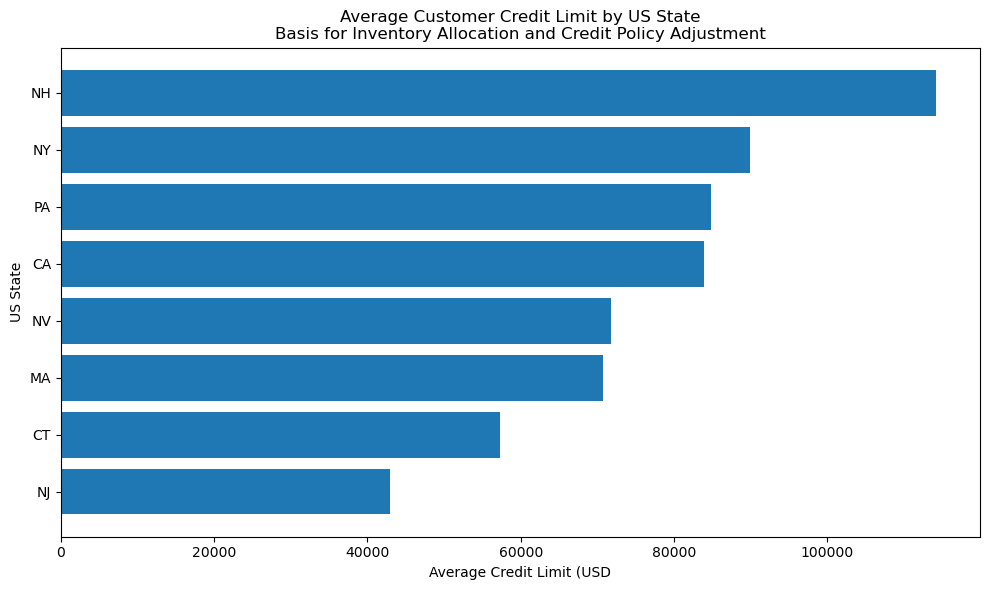

In [9]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
import matplotlib.pyplot as plt

US_Credit_Policy_sorted = US_Credit_Policy.sort_values('avg_credit_limit')

plt.figure(figsize=(10,6))
plt.barh(y='state', width='avg_credit_limit', data= US_Credit_Policy_sorted)
plt.xlabel('Average Credit Limit (USD')
plt.ylabel('US State')
plt.title('Average Customer Credit Limit by US State\nBasis for Inventory Allocation and Credit Policy Adjustment')
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [60]:
# Replace None with your code

Ann_top_Customers = pd.read_sql("""
    SELECT c.customerName, SUM(p.amount) AS total_payments
    FROM customers c
    LEFT JOIN payments p ON c.customerNumber = p.customerNumber
    GROUP BY c.customerNumber
    ORDER BY total_payments DESC
    LIMIT 10                                                           

""",conn)

Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

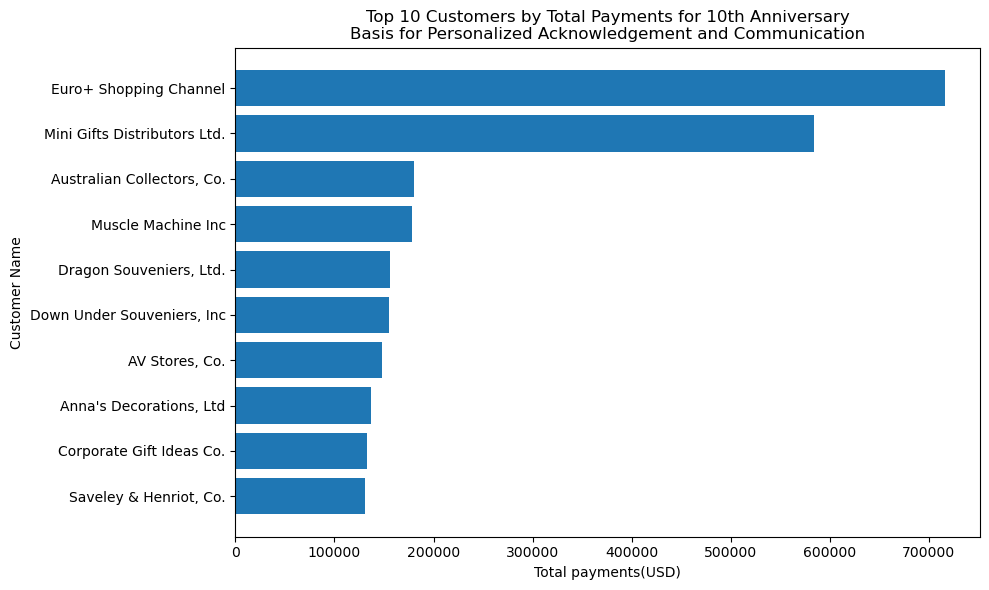

In [27]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
Ann_top_Customers_sorted = Ann_top_Customers.sort_values('total_payments')

plt.figure(figsize=(10,6))
plt.barh(y='customerName', width='total_payments', data=Ann_top_Customers_sorted)
plt.xlabel('Total payments(USD)')
plt.ylabel('Customer Name')
plt.title('Top 10 Customers by Total Payments for 10th Anniversary\nBasis for Personalized Acknowledgement and Communication')
plt.tight_layout()
plt.show()


### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [61]:
# Replace None with you code
popular_products = pd.read_sql("""
    SELECT 
            c.customerName, 
            p.productName, 
            SUM(od.quantityOrdered) as total_units_ordered, 
            SUM(od.quantityOrdered * od.priceEach) AS total_purchase_amount
    FROM products p
    LEFT JOIN orderdetails od ON p.productCode = od.productCode
    LEFT JOIN orders o ON od.orderNumber = o.orderNumber
    LEFT JOIN customers c ON o.customerNumber = c.customerNumber
    GROUP BY c.customerNumber, p.productCode
    HAVING total_units_ordered >= 10
    ORDER BY total_purchase_amount ASC                                                                                                                                                                                                 
""",conn)

### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [62]:
# Replace None with your code

product_Line_Demand = pd.read_sql("""
    SELECT 
        pl.productLine, 
        SUM(od.quantityOrdered) AS total_qty_ord, 
        COUNT(DISTINCT p.quantityInStock) AS total_no_products
    FROM productlines pl
    LEFT JOIN products p ON pl.productLine = p.productLine
    LEFT JOIN orderdetails od ON p.productCode = od.productCode
    GROUP BY pl.productLine

""",conn)

Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

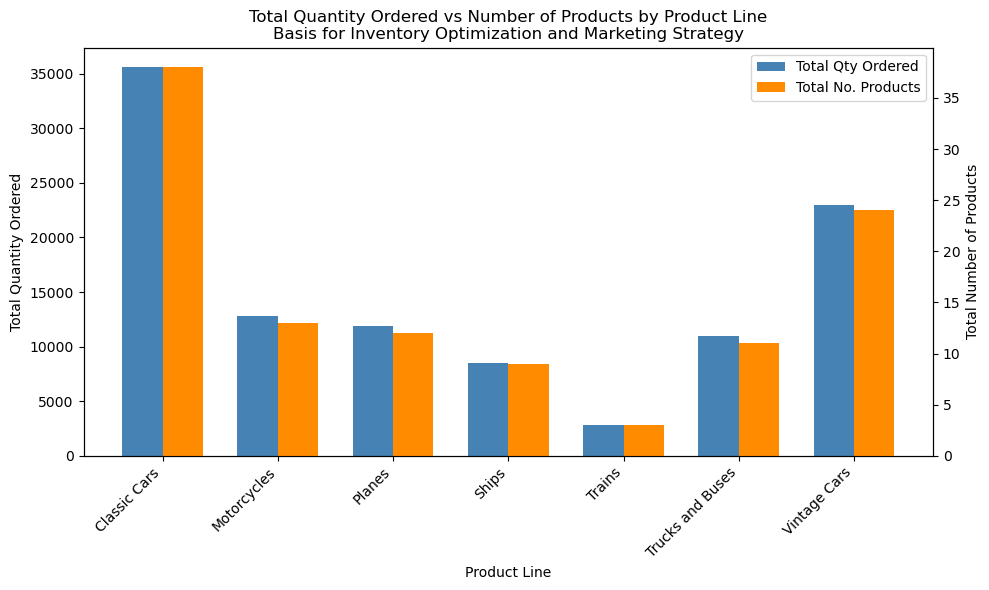

In [ ]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
fig, ax1 = plt.subplots(figsize=(10,6))

x = range(len(product_Line_Demand))
width = 0.35

bars1 = ax1.bar(
    [i - width/2 for i in x],
    product_Line_Demand['total_qty_ord'],
    width=width,
    label='Total Qty Ordered',
    color='steelblue'
)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    [i + width/2 for i in x],
    product_Line_Demand['total_no_products'],
    width=width,
    label='Total No. Products',
    color='darkorange'
)

ax1.set_xticks(list(x))
ax1.set_xticklabels(product_Line_Demand['productLine'], rotation=45, ha='right')
ax1.set_xlabel('Product Line')
ax1.set_ylabel('Total Quantity Ordered')
ax2.set_ylabel('Total Number of Products')

plt.title('Total Quantity Ordered vs Number of Products by Product Line\nBasis for Inventory Optimization and Marketing Strategy')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

The grouped bar chart was chosen because the core task is comparison — specifically, comparing two different measurements across the same set of categories simultaneously. Each product line needed to be evaluated on two dimensions at once: how many units customers are actually ordering, and how many distinct products exist within that line. A grouped bar chart places two bars side by side for each category, making it immediately obvious whether a product line is large in variety, large in demand, both, or neither — without the reader having to mentally cross-reference two separate charts. Any other chart type would have required either collapsing one of the metrics or splitting the information across multiple visuals, losing the comparative power that makes this analysis useful.<br>

In plain terms, think of it like comparing two sports teams across two statistics — points scored and fouls committed — displayed on the same scoreboard. You can instantly see who scores more and who fouls more without flipping between pages. That is exactly what this chart does for product lines. The left bar for each group tells you how busy that product line is in terms of actual customer orders, while the right bar tells you how wide the product catalogue is for that line. A tall left bar with a short right bar means customers love ordering from that line even though it has fewer products — a signal to invest in expanding it. A tall right bar with a short left bar means the company offers many products in that line but customers are not ordering much — a red flag for potential overstocking or weak market demand that marketing should address.<br>

In the context of the business question, the chart directly serves all four goals the product team outlined. It visually surfaces which product lines are most popular by demand, which have the most diverse offerings, and — crucially — whether diversity and demand move together or diverge. A product line where both bars are tall is a clear winner deserving continued investment. A line where the catalogue is wide but orders are low is a candidate for rationalisation or a targeted promotional push. These are not conclusions that require statistical expertise to reach — a manager looking at this chart for thirty seconds can identify the same priorities that would take considerably longer to extract from a raw data table, which is ultimately what a well-chosen visualization is supposed to accomplish.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [58]:
# Replace None with your code
empty_Offices = pd.read_sql("""
    SELECT 
        e.employeeNumber, 
        e.firstName, 
        e.lastName, 
        e.jobTitle,                    
        e.reportsTo,
        e.officeCode
    FROM employees e
    WHERE e.officeCode IN(
        SELECT o.officeCode
        FROM offices o
        JOIN employees e ON o.officeCode = e.officeCode
        GROUP BY o.officeCode
        HAVING COUNT(e.employeeNumber) < 5
    ) 
    ORDER BY e.officeCode                                                                               
""",conn)

## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

The starting point for designing the subquery was identifying what the main query could not determine on its own. The main query's job is straightforward — return employee details. But to filter the right employees, it first needs to know which offices qualify as "small." That qualification requires counting employees per office, which means aggregation — and you cannot filter on an aggregated value using a regular WHERE clause against the raw table. A WHERE COUNT(employeeNumber) < 5 directly in the main query is illegal in SQL because WHERE is evaluated before grouping happens. That constraint is what made a subquery the natural solution: push the aggregation into a separate, self-contained unit that runs first, resolves to a list of qualifying office codes, and hands that result to the main query to filter against. <br>

The subquery itself was designed by asking: "what is the minimum information needed to identify small offices?" The answer was two things — the officeCode as the linking key, and a count of employees per office to apply the HAVING filter. This meant the subquery needed its own JOIN between offices and employees to access both the office identifier and the employee count in the same scope. HAVING COUNT(employeeNumber) < 5 was used instead of WHERE because the filter applies to a grouped aggregate — HAVING is the correct clause for filtering after GROUP BY, just as WHERE filters before it. The result of the subquery is not a single value but a column of office codes — which is exactly why WHERE officeCode IN (subquery) was the right connector, since IN is designed to check membership against a list. The main query then runs against the full employees table, keeping only rows whose officeCode appears in that returned list — effectively letting the subquery do the qualification work so the outer query can stay focused on selecting and presenting the right employee details.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [ ]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [80]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

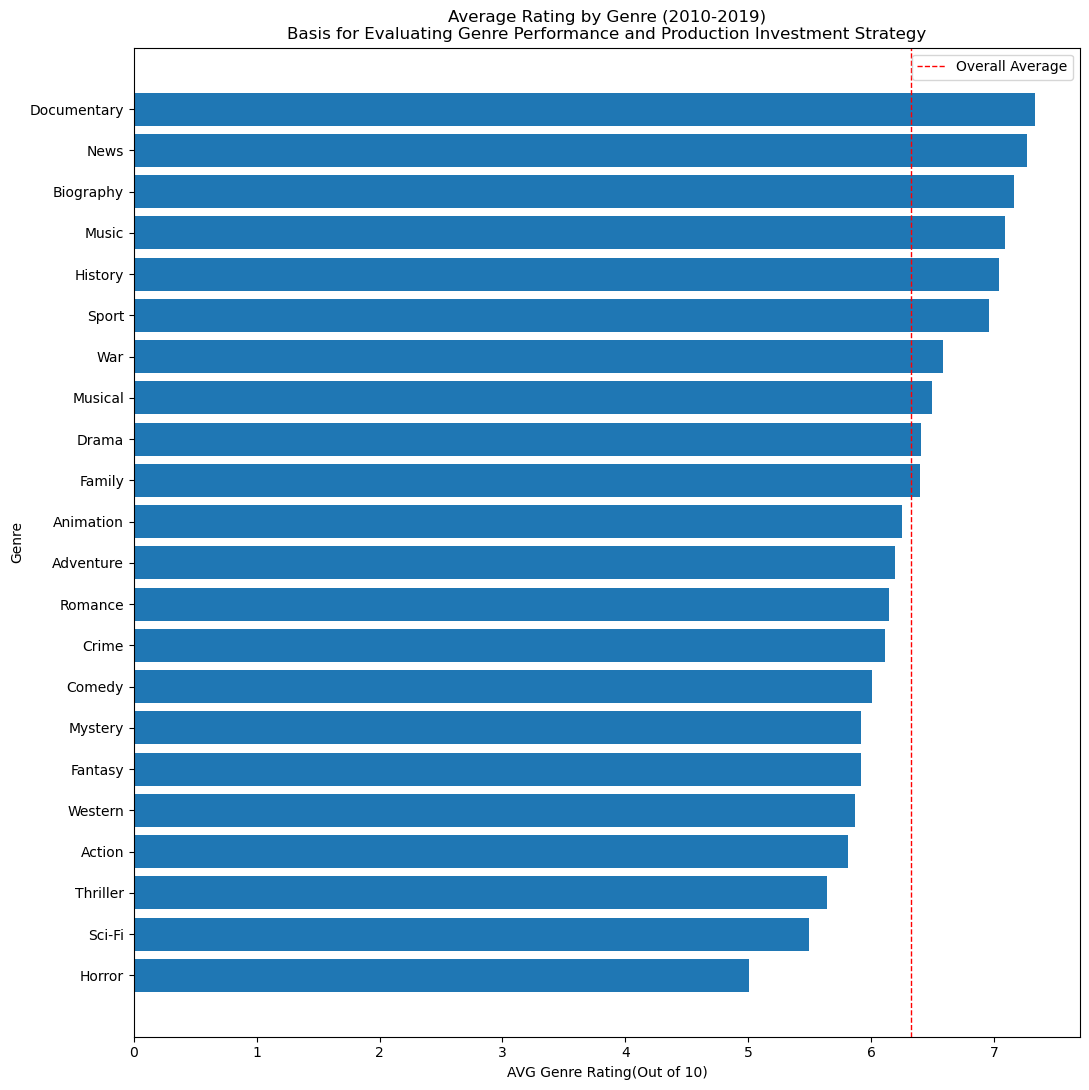

In [108]:
# Begin your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

raw_genres = pd.read_sql("""
    SELECT
        mb.genres,
        mr.averagerating,
        mr.numvotes
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
        AND mb.genres IS NOT NULL
        AND mr.averagerating IS NOT NULL
""", conn4)

# Step 2: Split comma-separated genres into lists
raw_genres['genres'] = raw_genres['genres'].str.split(',')

# Step 3: Explode — one row per genre per movie
raw_genres = raw_genres.explode('genres')

# Step 4: Clean whitespace
raw_genres['genres'] = raw_genres['genres'].str.strip()

# Step 5: Now aggregate properly
clean_genres = (
    raw_genres
    .groupby('genres')
    .agg(
        avg_rating=('averagerating', 'mean'),
        total_votes=('numvotes', 'sum'),
        total_movies=('genres', 'count')
    )
    .reset_index()
    .query('total_votes >= 10000')
    .sort_values('avg_rating', ascending=False)
)

plot_data = clean_genres.sort_values('avg_rating')

plt.figure(figsize=(11,11))
plt.barh(y='genres', width='avg_rating', data=plot_data)
plt.axvline(x=plot_data['avg_rating'].mean(), color='red', linestyle='--', linewidth=1, label='Overall Average')
plt.xlabel('AVG Genre Rating(Out of 10)')
plt.ylabel('Genre')
plt.title('Average Rating by Genre (2010-2019)\nBasis for Evaluating Genre Performance and Production Investment Strategy')
plt.legend()
plt.tight_layout()
plt.show()